In [1]:
import xarray as xr
import json

import sys
sys.path.append('../utils')
import dpa_ensemble as de
import utils as ut
import evaluation
import pandas as pd
import torch
import numpy as np
import os

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


##################
### set Domain ###
##################
abs_temps = False
### Germany ###
# coordinates 
#domain="GER"
#lat_min = 48
#lat_max = 54
#lon_min = 6
#lon_max = 15

### France ###
domain="FR"
lat_min = 45
lat_max = 50
lon_min= 0
lon_max= 5

### Spain ###
#domain="SP"
#lat_min = 38
#lat_max = 42
#lon_min = -8
#lon_max = 0

## Find max absolute temperatures

In [2]:
settings_file_path = f"../../settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
    
# load absolute temperatures
ds_1300 = xr.open_dataset(os.path.join(settings['paths']['other_data'],"TREFHT_day_b.e212.BHISTcmip6andSSP370cmip6.f09_g17.1300.nc"))

ds_abs_test_pre = ds_1300
ds_abs_test = ds_abs_test_pre.assign_coords(
    lon=((ds_abs_test_pre.lon + 180) % 360) - 180
).sortby("lon")


# cut data to domain
trefht_abs_test_ger_pre = ds_abs_test.TREFHT.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
print(trefht_abs_test_ger_pre)

ds_5day = trefht_abs_test_ger_pre.resample(time="5D", label="left").mean()
ds_5day = ds_5day.assign_coords(time=ds_5day.time + pd.Timedelta(days=2, hours=12))
ds_5day_jja = ds_5day.sel(time=ds_5day.time.dt.month.isin([6, 7, 8]))

# calculate weighted means
#weights
weights_ger_pre = np.cos(np.deg2rad(ds_5day_jja["lat"]))
weights_ger = weights_ger_pre / weights_ger_pre.sum()

# data
trefht_5day_jja_ger = ds_5day_jja.weighted(weights_ger).mean(dim=("lat", "lon"))

# get indexes of yearly max temperatures

s_abs = trefht_5day_jja_ger.to_series()                      # pandas Series with DatetimeIndex
t_max_abs = s_abs.groupby(s_abs.index.year).idxmax()

# integer indices in the original time axis (new, absolute values)
time_index_abs = pd.Index(trefht_5day_jja_ger.time.values)
idx_abs = time_index_abs.get_indexer(t_max_abs.values)

<xarray.DataArray 'TREFHT' (time: 91615, lat: 5, lon: 5)> Size: 9MB
[2290375 values with dtype=float32]
Coordinates:
  * time     (time) object 733kB 1850-01-01 00:00:00 ... 2100-12-31 00:00:00
  * lat      (lat) float64 40B 45.71 46.65 47.59 48.53 49.48
  * lon      (lon) float64 40B 0.0 1.25 2.5 3.75 5.0
Attributes:
    long_name:     Reference height temperature
    units:         K
    cell_methods:  time: mean


## Load DAE and test data

In [3]:
# Factual
# load true test data

### Load temperature test data ###
ds_test_eth_fact_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_transient'])
ds_test_eth_fact = xr.open_dataset(ds_test_eth_fact_path)
ds_test_eth_fact

### Load temperature data CF ###
ds_test_eth_cf_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_nudged_shifted'])
ds_test_eth_cf = xr.open_dataset(ds_test_eth_cf_path)
ds_test_eth_cf

# load DAE ensemble
model_path_pre = settings['paths']['output_dir']
model = settings['current_model']
model_path = os.path.join(model_path_pre, model)

# v5 
epochs=settings['epochs']

# counterfactual
dpa_eth_cf = xr.open_dataset(f"{model_path}/dae_ensemble_after_{epochs}_epochs/ETH_ensemble_after_{epochs}_epochs/ETH_cf_gen_dpa_ens_{epochs}_dataset_restored.nc")

In [4]:
### load climatology ###

# factual
eth_fact_1300_clim_pre = xr.open_dataset(os.path.join(settings['paths']['other_data'], "TREFHT_day_b.e212.BHISTcmip6_BSSP370cmip6.f09_g17.1300_1850-2100_clim.nc"))
display(eth_fact_1300_clim_pre)
eth_fact_1300_clim = eth_fact_1300_clim_pre.assign_coords(lon=((eth_fact_1300_clim_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact.lat, lon=ds_test_eth_fact.lon).sel(time=eth_fact_1300_clim_pre.time.dt.month.isin([6, 7, 8])).TREFHT
eth_fact_1300_clim


# calculate domain mean of climatology
domain_eth_fact_1300_clim_correct_pre = ut.get_ger_1d_data(eth_fact_1300_clim,
                                                        lat_min,
                                                        lat_max,
                                                        lon_min,
                                                        lon_max
                                                        )

domain_eth_fact_1300_clim_correct = np.tile(domain_eth_fact_1300_clim_correct_pre.values, (251))

# counterfactual
eth_cf_1300_clim_pre = xr.open_dataset(os.path.join(settings['paths']['other_data'], "TREFHT_day_b.e212.B1850cmip6.f09_g17.001.nudge-1850-2100-SSP370.1300.linear-weak_shifted-1day_clim.nc"))
display(eth_cf_1300_clim_pre)
eth_cf_1300_clim = eth_cf_1300_clim_pre.assign_coords(lon=((eth_cf_1300_clim_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact.lat, lon=ds_test_eth_fact.lon).sel(time=eth_cf_1300_clim_pre.time.dt.month.isin([6, 7, 8])).TREFHT


# calculate domain mean of climatology
domain_eth_cf_1300_clim_correct_pre = ut.get_ger_1d_data(eth_cf_1300_clim,
                                                        lat_min,
                                                        lat_max,
                                                        lon_min,
                                                        lon_max
                                                        )

domain_eth_cf_1300_clim_correct = np.tile(domain_eth_cf_1300_clim_correct_pre.values, (251))

<xarray.Dataset> Size: 16MB
Dimensions:  (time: 73, lon: 288, lat: 192)
Coordinates:
  * time     (time) object 584B 1980-01-03 00:00:00 ... 1980-12-29 00:00:00
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
Data variables:
    TREFHT   (time, lat, lon) float32 16MB ...
Attributes:
    CDI:               Climate Data Interface version 2.2.4 (https://mpimet.m...
    Conventions:       CF-1.0
    source:            CAM
    history:           Tue Jan 13 09:22:01 2026: cdo ydaymean temp_ref.nc /cl...
    case:              b.e212.BHISTcmip6.f09_g17.1300
    logname:           beyerleu
    initial_file:      b.e212.B1850cmip6.f09_g17.001.cam.i.1300-01-01-00000.nc
    topography_file:   /cluster/work/climate/cesm/inputdata/atm/cam/topo/fv_0...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1
    CDO:               Climate Data Operators version 2.2.2 (https://mpimet.m...

<xarray.Dataset> Size: 16MB
Dimensions:  (time: 73, lon: 288, lat: 192)
Coordinates:
  * time     (time) object 584B 1980-01-03 00:00:00 ... 1980-12-29 00:00:00
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
Data variables:
    TREFHT   (time, lat, lon) float32 16MB ...
Attributes:
    CDI:               Climate Data Interface version 2.2.4 (https://mpimet.m...
    Conventions:       CF-1.0
    source:            CAM
    history:           Tue Jan 13 09:14:00 2026: cdo ydaymean temp_ref.nc /cl...
    case:              b.e212.B1850cmip6.f09_g17.001.nudge-1850-2100-SSP370.1...
    logname:           beyerleu
    initial_file:      /cluster/work/climate/cesm/inputdata/atm/cam/inic/fv/c...
    topography_file:   /cluster/work/climate/cesm/inputdata/atm/cam/topo/fv_0...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1
    CDO:               Climate Data Operators version 2.2.2 (https://mpimet.m...

In [5]:
# calculate domain mean temperatures

################################
### domain mean of test data ###
################################

# Test data
trefht_eth = ds_test_eth_cf # anomalies still

# cut test data
trefht_eth_ger = trefht_eth.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# calculate weighted means
#weights
weights_ger_pre = np.cos(np.deg2rad(trefht_eth_ger["lat"]))
weights_ger = weights_ger_pre / weights_ger_pre.sum()

# test_data GER weighted mean
trefht_eth_ger_mean = trefht_eth_ger.TREFHT.weighted(weights_ger).mean(dim=("lat", "lon"))

# subset to member 1300
trefht_eth_ger_mean_1300 = trefht_eth_ger_mean.isel(time=slice(0,4769))


###############################
### domain mean of DAE data ###
###############################
# dpa ensemble of germany average (ensemble_member, )
dpa_ens_ger_1300 = dpa_eth_cf.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(weights_ger).mean(dim=('lat', 'lon')).isel(time=slice(0,4769))

# calculate ensemble median
dpa_ens_mean_ger_mean = dpa_ens_ger_1300.median(dim="ensemble_member")
dpa_ens_mean_ger_mean

<xarray.Dataset> Size: 76kB
Dimensions:  (time: 4769)
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (time) float64 38kB -4.318 1.036 0.7805 ... 2.427 -5.125 -0.8863

## Add quantile regression model

In [6]:
import sys
import utils as ut
import quantile_regression.pytorch_quantile_regression as pqr
import torch

qr_model_path = f"{model_path_pre}/QR_baseline/v5_quantile_regression_{domain}/"

with open(f"{qr_model_path}metadata.json", "r") as f:
    meta = json.load(f)

quantiles = meta["quantiles"]
n_features = meta["n_features"]
n_quantiles = len(quantiles)

# ---- Load checkpoint ----
#ckpt_path = meta["last_checkpoint"] # v4 model
ckpt_path = f"{qr_model_path}checkpoint_epoch_100.pth" # v5 model
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# ---- Rebuild model ----
model = pqr.LinearMultiQuantileRegressor(
    n_features=n_features,
    n_quantiles=n_quantiles
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# ---- Move to GPU (optional) ----
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

In [7]:
# ---- Prepare test data ----

# Load Z500 data
# train data 
z500_train_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_z500'])
z500_train_pre = xr.open_dataset(z500_train_path)
z500_train = z500_train_pre.pseudo_pcs.isel(time=slice(0,90*4769))
z500_train_np, mean_train, std_train = ut.standardize_numpy(z500_train.values) # get train statistics
pi_period_mean = z500_train_pre.pseudo_pcs.isel(mode=1000, time=slice(0,4769)).sel(time=slice("1850","1900")).mean().values #extract the mean fGMT in 1850-1900


z500_test_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_z500_eth_test'])
z500_test = xr.open_dataset(z500_test_path).pseudo_pcs.values
z500_test[:,-1] = pi_period_mean # insert counterfactual fGMT before standardization
z500_test_np, _, _ = ut.standardize_numpy(z500_test, mean_train, std_train)
print("cf_fgmt:", z500_test_np[:10,-1])

X_test_torch = torch.from_numpy(z500_test_np.astype("float32")).to(device)
print(X_test_torch.shape)


# ---- Predict from Qu. regression model ----
with torch.no_grad():
    preds = model(X_test_torch)   # shape (N_test, n_quantiles)
quantile_predictions = preds.cpu().numpy()

cf_fgmt: [-0.73911166 -0.73911166 -0.73911166 -0.73911166 -0.73911166 -0.73911166
 -0.73911166 -0.73911166 -0.73911166 -0.73911166]
torch.Size([14307, 1001])


## Plot

In [8]:
# Time series + right-side KDE-only marginal densities (no hist)
# KDE curves are side-by-side (three columns), with bumps to the LEFT
# and shaded area under each density.
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable


# ============================================================
# Helper: plot LEFT-pointing KDE in a fixed horizontal "column"
# ============================================================

def kde_column_left(ax, values, y_grid, x_center, width=0.22,
                    color="k", lw=2, alpha_fill=0.25, bw_method=None):
    """
    Plot a vertical KDE curve (density vs y) into a fixed column on ax,
    with the density extending to the LEFT of the column center and
    shaded under the curve.

    Mapping:
      dens_norm in [0,1]
      x = x_center - dens_norm * width   (so bumps go left)
      baseline = x_center

    Parameters
    ----------
    ax : matplotlib axis
    values : array-like
    y_grid : array-like
    x_center : float (0..1)
    width : float
    color : str
    lw : float
    alpha_fill : float
    bw_method : optional gaussian_kde bw_method
    """
    v = np.asarray(values).ravel()
    v = v[np.isfinite(v)]
    if v.size < 2:
        return

    kde = gaussian_kde(v, bw_method=bw_method)
    dens = kde(y_grid)

    dmax = np.nanmax(dens)
    if not np.isfinite(dmax) or dmax <= 0:
        return

    dens_norm = dens / dmax

    x_curve = x_center - dens_norm * width
    x_base = np.full_like(y_grid, x_center)

    # Shade under curve (between baseline and curve)
    ax.fill_betweenx(
        y_grid,
        x_curve,
        x_base,
        color=color,
        alpha=alpha_fill,
        linewidth=0
    )

    # Outline curve
    ax.plot(x_curve, y_grid, color=color, lw=lw)




DAE MAE: 0.799 °C
QR  MAE: 0.863 °C
[3.61417323 1.80708661]
ax width: 2.909 in, ax height: 1.214 in


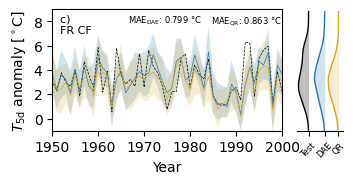

In [9]:
# ============================================================
# Figure
# ============================================================
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerBase
from matplotlib.transforms import Bbox


# add climatology to temperature anomalies
if abs_temps:
    truth_to_plot = trefht_eth_ger_mean_1300 + domain_eth_cf_1300_clim_correct -273.15
    dae_to_plot = dpa_ens_mean_ger_mean.TREFHT + domain_eth_fact_1300_clim_correct -273.15
    qr_to_plot = quantile_predictions[0:4769, 49] + domain_eth_fact_1300_clim_correct -273.15

else:
    truth_to_plot = trefht_eth_ger_mean_1300
    dae_to_plot = dpa_ens_mean_ger_mean.TREFHT
    qr_to_plot = quantile_predictions[0:4769, 49]
    

# set year index
da_max_year_pre = np.arange(1850,2101,1)
 

# Set figure width to match LaTeX \textwidth (6.02 inches)
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = 0.6 * (FIG_WIDTH_MM / 25.4)
FIG_HEIGHT_IN = 0.3 * (FIG_WIDTH_MM / 25.4)


fig, ax = plt.subplots(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))



FONT_SIZE = 8

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE - 1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})




n_stds=2
qr_color="goldenrod"
dae_color="tab:blue"
# --- main time series ---

# truth
ax.plot(
    da_max_year_pre, #.year.values,
    truth_to_plot.values[idx_abs],
    label=r"$\mathrm{Test: ETH^{1300}_{cf}}$",
    color="black",
    linestyle="--",
    linewidth=0.5
    
)

# DPA ensemble mean
ax.plot(
    da_max_year_pre, #.year.values,
    dae_to_plot.isel(time=idx_abs).values,
    color=dae_color,
    label="DAE median",
    linewidth=0.5,
)

# --- envelopes ---

quantile_lower = 0.05
quantile_upper = 0.95
if abs_temps:
    dpa_quantiles = (dpa_ens_ger_1300.TREFHT+ domain_eth_fact_1300_clim_correct -273.15).quantile([quantile_lower, quantile_upper], dim="ensemble_member")
else:
    dpa_quantiles = (dpa_ens_ger_1300.TREFHT).quantile([quantile_lower, quantile_upper], dim="ensemble_member")
lower_env_dpa = dpa_quantiles.sel(quantile=quantile_lower) #+ domain_eth_fact_1300_clim_correct -273.15
upper_env_dpa = dpa_quantiles.sel(quantile=quantile_upper) #+ domain_eth_fact_1300_clim_correct -273.15

ax.fill_between(
    da_max_year_pre, #.year.values,
    lower_env_dpa.isel(time=idx_abs).values,
    upper_env_dpa.isel(time=idx_abs).values,
    alpha=0.2,
    #label=f"DAE: 0.05–0.95 quantile range",
    color=dae_color,
    edgecolor="none"
)


# quantile regression median
ax.plot(
    da_max_year_pre, #.year.values,
    qr_to_plot[idx_abs],
    color=qr_color,
    label="QR median",
    linewidth=0.5
)

# quantile interval (0.05–0.95)
if abs_temps:
    lower_env = (quantile_predictions[0:4769, 4]+ domain_eth_fact_1300_clim_correct -273.15)[idx_abs] 
    upper_env = (quantile_predictions[0:4769, 94]+ domain_eth_fact_1300_clim_correct -273.15)[idx_abs] 

else:
    lower_env = (quantile_predictions[0:4769, 4])[idx_abs] 
    upper_env = (quantile_predictions[0:4769, 94])[idx_abs]

ax.fill_between(
    da_max_year_pre, #.year.values,
    lower_env,
    upper_env,
    color=qr_color,
    alpha=0.2,
    edgecolor="none"
)

# --- main axis formatting ---
ax.set_xlabel("Year")
#ax.set_ylabel("Annual max. " + r"$T_{\mathrm{5d}}$ [$^\circ$C]")
#ax.set_ylabel(r"$T_{\mathrm{5d}}$ anomaly at annual max. $T_{\mathrm{5d}}$ [$^\circ$C]")
ax.set_ylabel(r"$T_{\mathrm{5d}}$ anomaly [$^\circ$C]")

ax.set_xlim(1950, 2000)

# ============================================================
# Right marginal axis (KDE-only, left-pointing, shaded)
# ============================================================

divider = make_axes_locatable(ax)
ax_dist = divider.append_axes(
    "right",
    size="20%",
    pad=0.15,
    sharey=ax
)

# --- data for marginal KDEs ---
if abs_temps:
    truth_vals = (trefht_eth_ger_mean_1300.values + domain_eth_cf_1300_clim_correct -273.15)[idx_abs][100:150]
    model_vals = (quantile_predictions[0:4769, :] + domain_eth_fact_1300_clim_correct[:, np.newaxis] - 273.15)[idx_abs][100:150, :]
    dpa_vals = (dpa_ens_ger_1300.TREFHT + domain_eth_fact_1300_clim_correct - 273.15)[:, idx_abs].values[:,100:150].ravel()

else:
    truth_vals = trefht_eth_ger_mean_1300.values[idx_abs][100:150]
    model_vals = quantile_predictions[0:4769, :][idx_abs][100:150, :]
    dpa_vals = dpa_ens_ger_1300.TREFHT[:, idx_abs].values[:,100:150].ravel()

# y-grid for KDE evaluation (cover all distributions)
y_min = np.nanmin([np.nanmin(truth_vals), np.nanmin(model_vals), np.nanmin(dpa_vals)])
y_max = np.nanmax([np.nanmax(truth_vals), np.nanmax(model_vals), np.nanmax(dpa_vals)])
y_pad = 0.05 * (y_max - y_min) if (y_max > y_min) else 1.0
y_grid = np.linspace(y_min - y_pad, y_max + y_pad, 400)

# Clear and plot KDE columns (separate x-centers, no overlap)
ax_dist.cla()

# Columns: truth | DPA | QR
kde_column_left(ax_dist, truth_vals, y_grid, x_center=0.25, width=0.22,
                color="black", lw=1, alpha_fill=0.25)
kde_column_left(ax_dist, dpa_vals,   y_grid, x_center=0.60, width=0.22,
                color=dae_color, lw=1, alpha_fill=0.20)
kde_column_left(ax_dist, model_vals, y_grid, x_center=0.90, width=0.22,
                color=qr_color, lw=1, alpha_fill=0.20)

# Styling
ax_dist.set_xlim(0, 1)
ax_dist.set_xticks([0.25, 0.60, 0.90])
ax_dist.set_xticklabels(["Test", "DAE", "QR"], fontsize = 6, rotation=45)

ax_dist.yaxis.set_visible(False)
ax_dist.spines["top"].set_visible(False)
ax_dist.spines["right"].set_visible(False)
ax_dist.spines["left"].set_visible(False)

# ============================================================
# Final layout
# ============================================================
# Add text in upper-right corner
ax.text(
    0.035, 0.96,      # x=0.95, y=0.95 in axes coordinates (0-1)
    f"c) \n{domain} CF",   # text to display
    transform=ax.transAxes,  # use axes coordinates
    ha='left',      # horizontal alignment
    va='top',        # vertical alignment
    fontsize=8,
    color='black'
)

# ADD PATCH
# two-color legend entry
patch1 = mpatches.Patch(facecolor=dae_color, alpha=0.2, edgecolor='none')
patch2 = mpatches.Patch(facecolor=qr_color, alpha=0.2, edgecolor='none')

# existing legend items
handles, labels = ax.get_legend_handles_labels()

# append tuple of patches
handles.append((patch1, patch2))
labels.append("DAE / QR 0.05–0.95 quantile range")

if False:
    ax.legend(
        handles=handles,
        labels=labels,
        handler_map={tuple: HandlerTuple(ndivide=None)},
        loc='lower center',           # anchor point of the legend
        bbox_to_anchor=(0.5, 1.02),  # (x, y) in axes coordinates
        ncol=2,                       # horizontal layout
        frameon=False,                # no frame
        fontsize=6
    )



# anomalies for caluclating MAEs
truth_vals = trefht_eth_ger_mean_1300.values[idx_abs][100:150]
dae_vals = dpa_ens_mean_ger_mean.TREFHT.isel(time=idx_abs).values[100:150]
qr_vals = quantile_predictions[0:4769, 49][idx_abs][100:150]


# Mean Absolute Errors
mae_dae = np.mean(np.abs(truth_vals - dae_vals))
mae_qr  = np.mean(np.abs(truth_vals - qr_vals))

print(f"DAE MAE: {mae_dae:.3f} °C")
print(f"QR  MAE: {mae_qr:.3f} °C")

ax.text(
    0.65, 0.96,      # x=0.95, y=0.95 in axes coordinates (0-1)
    r"$\mathrm{MAE_{DAE}}$"+f": {mae_dae:.3f} °C",   # text to display
    transform=ax.transAxes,  # use axes coordinates
    ha='right',      # horizontal alignment
    va='top',        # vertical alignment
    fontsize=6,
    color='black'
)

ax.text(
    1.0, 0.96,      # x=0.95, y=0.95 in axes coordinates (0-1)
    r"$\mathrm{MAE_{QR}}$"+f": {mae_qr:.3f} °C",   # text to display
    transform=ax.transAxes,  # use axes coordinates
    ha='right',      # horizontal alignment
    va='top',        # vertical alignment
    fontsize=6,
    color='black'
)

plt.tight_layout()

if abs_temps:
    if domain == "FR":
        plt.ylim(18, 29)
        ax.set_yticks([18,20, 22, 24, 26, 28])
    if domain == "GER":
        plt.ylim(16, 28)
        ax.set_yticks([16, 18,20, 22, 24, 26, 28])
    if domain == "SP":
        plt.ylim(23, 30)
        ax.set_yticks([24, 26, 28, 30, 32])
else:
    if domain == "FR":
        plt.ylim(-1, 9)
        ax.set_yticks([0, 2, 4, 6, 8])
    if domain == "GER":
        plt.ylim(0, 11)
        ax.set_yticks([0, 2, 4, 6, 8, 10])
    if domain == "SP":
        plt.ylim(-2, 7)
        ax.set_yticks([-2, 0, 2, 4, 6])


# set correct figure size
fig_w, fig_h = fig.get_size_inches()   # 3.614, 1.807 (same FIG_WIDTH_MM/FIG_HEIGHT_IN as before)

# Target axes size (in inches) — the values you want to match
target_ax_width_in = 2.909
target_ax_height_in = 1.214

# Keep whatever left/bottom offset your current layout has, or set your own
x0_in, y0_in = 0.45, 0.35   # <-- adjust to taste / to match visually

new_pos = Bbox.from_bounds(
    x0_in / fig_w,
    y0_in / fig_h,
    target_ax_width_in / fig_w,
    target_ax_height_in / fig_h
)
ax.set_position(new_pos)


print(fig.get_size_inches())
bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
print(f"ax width: {bbox.width:.3f} in, ax height: {bbox.height:.3f} in")

# legend
#plt.savefig(f"legend_fig03_{domain}_CF_updated.pdf")

# no legend
if abs_temps:
    plt.savefig(f"fig03_{domain}_CF_updated_entire_distribution.pdf", bbox_inches="tight")
else:
    plt.savefig(f"fig03_{domain}_CF_updated_entire_distribution_anoms.pdf", bbox_inches="tight")
    


plt.show()